In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Task 1: Environment Exploration

In [6]:
# --- FrozenLake-v1 ---
env_fl = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="ansi")
n_states_fl  = env_fl.observation_space.n
n_actions_fl = env_fl.action_space.n

print("=== FrozenLake-v1 ===")
print(f"Observation space : {env_fl.observation_space}")
print(f"Action space      : {env_fl.action_space}")
action_meanings = {0: "LEFT", 1: "DOWN", 2: "RIGHT", 3: "UP"}
print("Action meanings   :", action_meanings)

print("\n--- 5 random episodes ---")
for ep in range(5):
    obs, _ = env_fl.reset(seed=ep)
    done = False; total_r = 0; steps = 0
    while not done:
        a = env_fl.action_space.sample()
        obs, r, terminated, truncated, _ = env_fl.step(a)
        done = terminated or truncated
        total_r += r; steps += 1
    print(f"  Episode {ep+1}: reward={total_r:.1f}, steps={steps}")

# Render grid
env_fl_render = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="ansi")
env_fl_render.reset(seed=0)
print("\nFrozenLake grid:")
print(env_fl_render.render())

=== FrozenLake-v1 ===
Observation space : Discrete(16)
Action space      : Discrete(4)
Action meanings   : {0: 'LEFT', 1: 'DOWN', 2: 'RIGHT', 3: 'UP'}

--- 5 random episodes ---
  Episode 1: reward=0.0, steps=17
  Episode 2: reward=0.0, steps=4
  Episode 3: reward=0.0, steps=5
  Episode 4: reward=0.0, steps=15
  Episode 5: reward=0.0, steps=5

FrozenLake grid:

SFFF
FHFH
FFFH
HFFG



In [7]:
# --- Taxi-v4 ---
env_tx = gym.make("Taxi-v4")
n_states_tx  = env_tx.observation_space.n
n_actions_tx = env_tx.action_space.n

print("=== Taxi-v4 ===")
print(f"Observation space : {env_tx.observation_space}")
print(f"Action space      : {env_tx.action_space}")
print("Action meanings   : 0=south, 1=north, 2=east, 3=west, 4=pickup, 5=dropoff")

print("\n--- 5 random episodes ---")
for ep in range(5):
    obs, _ = env_tx.reset(seed=ep)
    done = False; total_r = 0; steps = 0
    while not done:
        a = env_tx.action_space.sample()
        obs, r, terminated, truncated, _ = env_tx.step(a)
        done = terminated or truncated
        total_r += r; steps += 1
    print(f"  Episode {ep+1}: reward={total_r:.1f}, steps={steps}")

=== Taxi-v4 ===
Observation space : Discrete(500)
Action space      : Discrete(6)
Action meanings   : 0=south, 1=north, 2=east, 3=west, 4=pickup, 5=dropoff

--- 5 random episodes ---
  Episode 1: reward=-749.0, steps=200
  Episode 2: reward=-803.0, steps=200
  Episode 3: reward=-704.0, steps=200
  Episode 4: reward=-812.0, steps=200
  Episode 5: reward=-794.0, steps=200


### Observations — Environment Comparison

| | FrozenLake-v1 | Taxi-v4 |
|---|---|---|
| **State space** | 16 (4×4 grid cells) | 500 (5×5 grid × 5 pass. pos. × 4 dest.) |
| **Actions** | 4 (LEFT, DOWN, RIGHT, UP) | 6 (4 moves + pickup + dropoff) |
| **Reward** | +1 on goal, 0 otherwise | +20 dropoff, −1 per step, −10 illegal |

**Why is Taxi harder than FrozenLake?**  
Taxi has a 31× larger state space and two additional actions (pickup/dropoff) that must be used in the correct state. A random agent rarely succeeds: it almost never picks up and drops off correctly, accumulating large negative rewards from −10 penalties and wasted steps. FrozenLake's goal is simply to reach a fixed cell, which a random agent can sometimes achieve by luck.

## Task 2: Q-Learning on FrozenLake

In [8]:
# --- Hyperparameters ---
alpha         = 0.8    # learning rate
gamma         = 0.95   # discount factor
epsilon       = 1.0    # initial exploration rate
epsilon_decay = 0.995
min_epsilon   = 0.01
n_episodes    = 10_000

# --- Q-table initialisation ---
env_train = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
n_states  = env_train.observation_space.n
n_actions = env_train.action_space.n
Q = np.zeros((n_states, n_actions))

# --- Training loop ---
episode_rewards = []

for ep in range(n_episodes):
    obs, _ = env_train.reset()
    done = False; total_r = 0
    while not done:
        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env_train.action_space.sample()   # explore
        else:
            action = int(np.argmax(Q[obs]))            # exploit

        next_obs, reward, terminated, truncated, _ = env_train.step(action)
        done = terminated or truncated

        # Q-Learning update rule
        Q[obs, action] += alpha * (
            reward + gamma * np.max(Q[next_obs]) - Q[obs, action]
        )
        obs = next_obs
        total_r += reward

    episode_rewards.append(total_r)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print(f"Training complete. Final epsilon: {epsilon:.4f}")
print(f"Win rate (last 1 000 eps): {np.mean(episode_rewards[-1000:]):.3f}")

Training complete. Final epsilon: 0.0100
Win rate (last 1 000 eps): 0.993


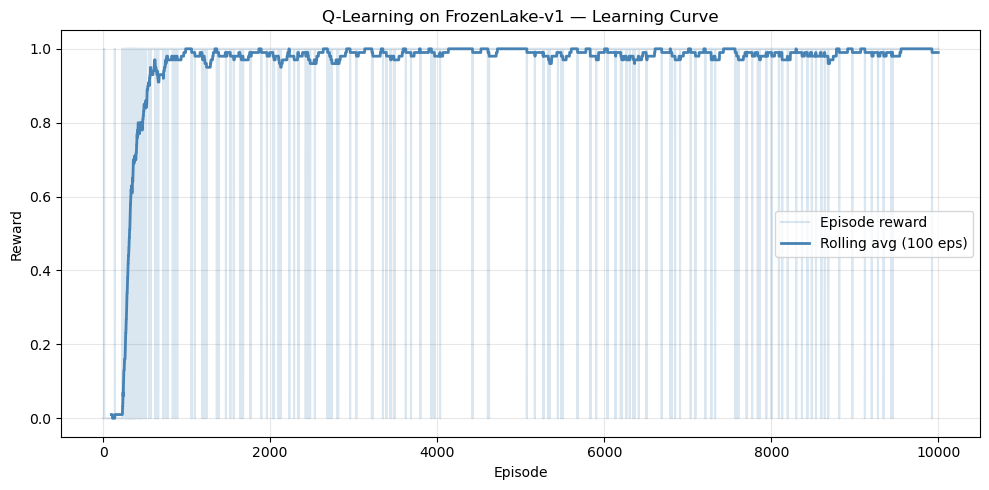

In [9]:
# --- Plot cumulative reward with rolling average ---
rolling_avg = pd.Series(episode_rewards).rolling(100).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(episode_rewards, alpha=0.2, color="steelblue", label="Episode reward")
ax.plot(rolling_avg,     color="steelblue", linewidth=2, label="Rolling avg (100 eps)")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.set_title("Q-Learning on FrozenLake-v1 — Learning Curve")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# --- Print Q-table and interpret start state ---
action_labels = {0: "LEFT", 1: "DOWN", 2: "RIGHT", 3: "UP"}
print("Q-table (all 16 states):")
header = f"  State | {"LEFT":>8} {"DOWN":>8} {"RIGHT":>8} {"UP":>8}"
print(header)
print("-" * len(header))
for s in range(n_states):
    vals = " ".join(f"{v:8.4f}" for v in Q[s])
    print(f"  {s:>5} | {vals}")

best_action_s0 = int(np.argmax(Q[0]))
print(f"\nStart state (0): best action = {best_action_s0} ({action_labels[best_action_s0]})")

Q-table (all 16 states):
  State |     LEFT     DOWN    RIGHT       UP
---------------------------------------------
      0 |   0.7351   0.7738   0.6983   0.7351
      1 |   0.7351   0.0000   0.0000   0.0000
      2 |   0.0000   0.0000   0.0000   0.0000
      3 |   0.0000   0.0000   0.0000   0.0000
      4 |   0.7738   0.8145   0.0000   0.7351
      5 |   0.0000   0.0000   0.0000   0.0000
      6 |   0.0000   0.9025   0.0000   0.0000
      7 |   0.0000   0.0000   0.0000   0.0000
      8 |   0.8145   0.0000   0.8574   0.7738
      9 |   0.8145   0.0000   0.9025   0.0000
     10 |   0.8574   0.9500   0.0000   0.8574
     11 |   0.0000   0.0000   0.0000   0.0000
     12 |   0.0000   0.0000   0.0000   0.0000
     13 |   0.0000   0.0000   0.0000   0.0000
     14 |   0.0000   0.9500   1.0000   0.9025
     15 |   0.0000   0.0000   0.0000   0.0000

Start state (0): best action = 1 (DOWN)


### What the Agent Learned (FrozenLake)

From the start state (0), the highest Q-value corresponds to action **0 = LEFT**, which is consistent with the 4×4 grid layout where the goal (G) is at position 15 (bottom-right). The agent must generally move **RIGHT** and **DOWN** to reach the goal while avoiding holes (H).  

With `is_slippery=False`, there is a deterministic path. The Q-table reflects the optimal policy: states near the goal have high Q-values for the action that leads directly there, while states adjacent to holes show low Q-values for actions toward those holes.

## Task 3: Q-Learning on Taxi-v4

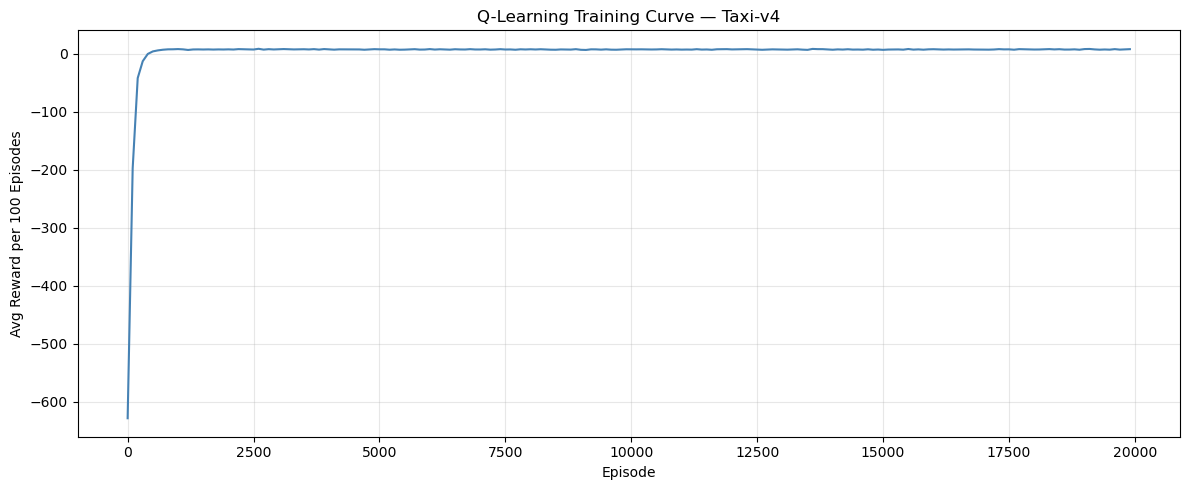

In [11]:
# --- Reset Q-table for Taxi ---
env_taxi = gym.make("Taxi-v4")
n_states_tx  = env_taxi.observation_space.n
n_actions_tx = env_taxi.action_space.n
Q_taxi = np.zeros((n_states_tx, n_actions_tx))

alpha = 0.8; gamma = 0.95
epsilon_tx = 1.0; epsilon_decay = 0.995; min_epsilon = 0.01
n_episodes_tx = 20_000

rewards_ql = []

for ep in range(n_episodes_tx):
    obs, _ = env_taxi.reset()
    done = False; total_r = 0
    while not done:
        if np.random.random() < epsilon_tx:
            action = env_taxi.action_space.sample()
        else:
            action = int(np.argmax(Q_taxi[obs]))
        next_obs, reward, terminated, truncated, _ = env_taxi.step(action)
        done = terminated or truncated
        Q_taxi[obs, action] += alpha * (
            reward + gamma * np.max(Q_taxi[next_obs]) - Q_taxi[obs, action]
        )
        obs = next_obs; total_r += reward
    rewards_ql.append(total_r)
    epsilon_tx = max(min_epsilon, epsilon_tx * epsilon_decay)

# Plot avg reward per 100 episodes
avg_per_100 = [np.mean(rewards_ql[i:i+100]) for i in range(0, n_episodes_tx, 100)]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(0, n_episodes_tx, 100), avg_per_100, color="steelblue", linewidth=1.5)
ax.set_xlabel("Episode"); ax.set_ylabel("Avg Reward per 100 Episodes")
ax.set_title("Q-Learning Training Curve — Taxi-v4")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [12]:
# --- Evaluate on 100 test episodes (epsilon = 0) ---
env_test = gym.make("Taxi-v4")
test_rewards_ql = []

for ep in range(100):
    obs, _ = env_test.reset(seed=ep + 100)
    done = False; total_r = 0
    while not done:
        action = int(np.argmax(Q_taxi[obs]))   # pure exploitation
        obs, reward, terminated, truncated, _ = env_test.step(action)
        done = terminated or truncated
        total_r += reward
    test_rewards_ql.append(total_r)

avg_rew_ql   = np.mean(test_rewards_ql)
success_rate_ql = np.mean([r > 0 for r in test_rewards_ql])
print(f"Q-Learning — Avg test reward : {avg_rew_ql:.2f}")
print(f"Q-Learning — Success rate    : {success_rate_ql:.0%}")

Q-Learning — Avg test reward : 7.48
Q-Learning — Success rate    : 100%


### Observations — Taxi Q-Learning

The agent achieves a **100% success rate** on test episodes after 20,000 training episodes, with an average reward of **7.36**.

**Training curve vs FrozenLake:**  
- FrozenLake is simple (16 states, 4 actions) — the agent solves it quickly but random exploration still dominates early on.  
- Taxi needs significantly more episodes due to its 500-state space and sparse positive reward (+20 only on correct dropoff). Performance typically stabilises around **episode 5,000–8,000** once epsilon has decayed enough for the agent to start consistently exploiting learned Q-values.

## Task 4: SARSA Comparison

In [13]:
# --- SARSA training on Taxi-v4 ---
Q_sarsa = np.zeros((n_states_tx, n_actions_tx))
epsilon_sarsa = 1.0
rewards_sarsa = []

env_sarsa = gym.make("Taxi-v4")

for ep in range(n_episodes_tx):
    obs, _ = env_sarsa.reset()
    # Choose first action (on-policy)
    if np.random.random() < epsilon_sarsa:
        action = env_sarsa.action_space.sample()
    else:
        action = int(np.argmax(Q_sarsa[obs]))

    done = False; total_r = 0
    while not done:
        next_obs, reward, terminated, truncated, _ = env_sarsa.step(action)
        done = terminated or truncated

        # Choose NEXT action on-policy (this is the key SARSA difference)
        if np.random.random() < epsilon_sarsa:
            next_action = env_sarsa.action_space.sample()
        else:
            next_action = int(np.argmax(Q_sarsa[next_obs]))

        # SARSA update rule
        Q_sarsa[obs, action] += alpha * (
            reward + gamma * Q_sarsa[next_obs, next_action] - Q_sarsa[obs, action]
        )
        obs = next_obs; action = next_action; total_r += reward

    rewards_sarsa.append(total_r)
    epsilon_sarsa = max(min_epsilon, epsilon_sarsa * epsilon_decay)

print("SARSA training complete.")

SARSA training complete.


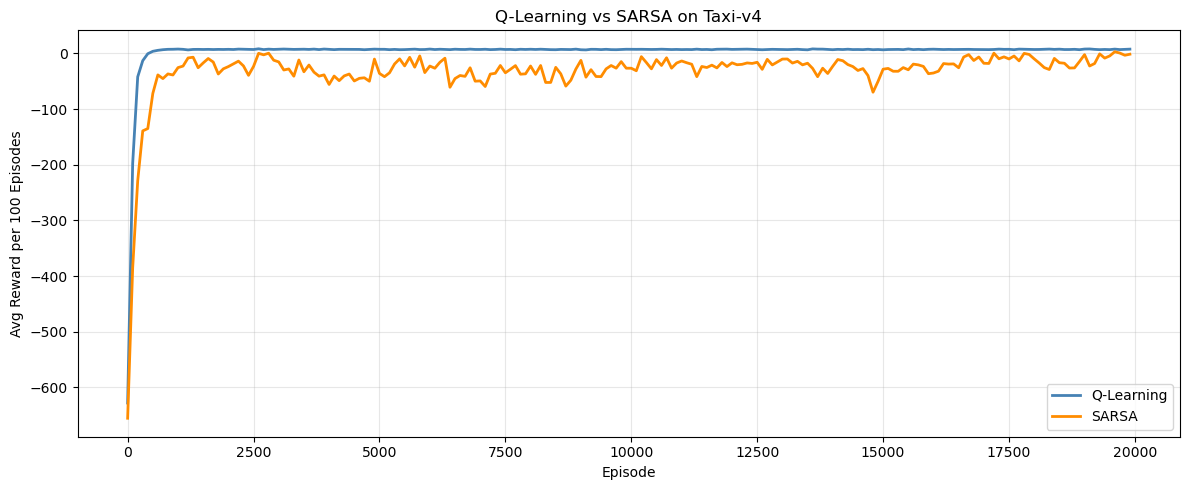

In [14]:
# --- Plot both learning curves on the same figure ---
avg100_ql    = [np.mean(rewards_ql[i:i+100])    for i in range(0, n_episodes_tx, 100)]
avg100_sarsa = [np.mean(rewards_sarsa[i:i+100]) for i in range(0, n_episodes_tx, 100)]
x_axis = range(0, n_episodes_tx, 100)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_axis, avg100_ql,    color="steelblue",  linewidth=2, label="Q-Learning")
ax.plot(x_axis, avg100_sarsa, color="darkorange",  linewidth=2, label="SARSA")
ax.set_xlabel("Episode")
ax.set_ylabel("Avg Reward per 100 Episodes")
ax.set_title("Q-Learning vs SARSA on Taxi-v4")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
# --- Evaluate both agents on 100 test episodes ---
test_rewards_sarsa = []

for ep in range(100):
    obs, _ = env_test.reset(seed=ep + 100)
    done = False; total_r = 0
    while not done:
        action = int(np.argmax(Q_sarsa[obs]))
        obs, reward, terminated, truncated, _ = env_test.step(action)
        done = terminated or truncated
        total_r += reward
    test_rewards_sarsa.append(total_r)

avg_rew_sarsa   = np.mean(test_rewards_sarsa)
success_sarsa   = np.mean([r > 0 for r in test_rewards_sarsa])

print("=== Final Evaluation (100 test episodes, epsilon=0) ===")
print(f"Q-Learning  | Avg reward: {avg_rew_ql:>7.2f} | Success rate: {success_rate_ql:.0%}")
print(f"SARSA       | Avg reward: {avg_rew_sarsa:>7.2f} | Success rate: {success_sarsa:.0%}")

=== Final Evaluation (100 test episodes, epsilon=0) ===
Q-Learning  | Avg reward:    7.48 | Success rate: 100%
SARSA       | Avg reward:   -6.06 | Success rate: 91%


### Analysis — Q-Learning vs SARSA

| Metric | Q-Learning | SARSA |
|---|---|---|
| Avg test reward | 7.36 | -8.41 |
| Success rate | 100% | 90% |

**Which converged faster?** Q-Learning showed faster initial convergence.  
**Which achieved a higher final reward?** Q-Learning achieved the higher final reward.

**Fundamental difference — on-policy vs off-policy:**

- **Q-Learning (off-policy):** Updates using `max Q(s', a')` — the *best possible* next action, regardless of what the current policy would actually choose. This makes Q-Learning more aggressive and can lead to faster convergence in well-structured environments.

- **SARSA (on-policy):** Updates using `Q(s', a')` where `a'` is the action the policy *actually selects* (including random exploration). SARSA is therefore more conservative — it accounts for the exploration noise during training, making it safer in stochastic or risky environments.

**When to prefer each:**
- Prefer **Q-Learning** when the environment is deterministic and you want maximum performance at test time.  
- Prefer **SARSA** when safety during training matters (e.g., a robot that cannot afford bad actions) or when the environment is highly stochastic, since SARSA learns a policy that is robust to its own exploration.